In [1]:
# import
import os, sys
import numpy as np
import pandas as pd

# import plotting libraries
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 10})
plt.rcParams["svg.fonttype"] = "none"

sys.path.extend([r'/home/lindenmp/research_projects/snaplab_tools'])
from snaplab_tools.plotting.plotting import categorical_kde_plot, null_plot
from snaplab_tools.plotting.utils import get_my_colors
from snaplab_tools.prediction.regression import Regression
from snaplab_tools.utils import get_null_p

# Load data

First, let's load some data from the HCP. 

We will load a pair of 2D numpy matrices. The first will be an (n_subjects, n_nodes) matrix of intracortical myelin content; this is extracted from the T1w/T2w ratio. The second will be an (n_subjects, n_nodes) matrix of intrinsic neural time scales; this is extracted by quantifying the decay of an autocorrelation function fit to regional resting-state fMRI time series.

Note, this data is not provided with this tutorial. If you want to execute this notebook, you will need to provide your own data.

In [2]:
# directory where data is stored
indir = '/home/lindenmp/research_projects/nct_xr/data'
outdir = '/home/lindenmp/research_projects/nct_xr/results'

myelin_file = os.path.join(indir, 'hcp_schaefer400-7_myelin.npy')
myelin = np.load(myelin_file).T
print(myelin.shape)

rsacf_file = os.path.join(indir, 'hcp_schaefer400-7_rsacf.npy')
rsacf = np.load(rsacf_file)[:, 0, :].T
print(rsacf.shape)

(728, 400)
(728, 400)


You can see from the above that we have 728 subjects (rows) and 400 brain regions (columns).

We will also load demographic and cognitive data for the same HCP subjects into a pandas dataframe.

In [3]:
df = pd.read_csv(os.path.join(indir, 'hcp_schaefer400-7_df.csv'), index_col=0)
n_subs = df.shape[0]
print(n_subs)
# df.head()

728


# Regression

## Set regression parameters

To run the Regression class, we need to setup some parameters for the model

In [4]:
alg = 'rr'  # chooce a regression algorithm. rr = ridge regression
score = 'rmse'  # choose a primary scorer. rmse = root mean squared error
secondary_score = 'corr'  # choose a secondary scorer. corr = correlation between true and predicted y
n_splits = 5  # chooce number of folds for k-fold cross-validation
runpca = '1%'  # choose whether to incorporate a PCA. Options are [False, '1%', '80%'] or an integer value.
n_rand_splits = 100  # choose how many times to run the entire analysis with a different ordering of the data. This effects the splits of the data in k-fold cross-validation
n_perm = 500  # choose how many random permutations to do in order to generate an empirical null. Note, for the tutorial I'm just doing 500 permutations, but you'd want to do more like 5,000-10,000 permutations for a paper

## Extract dependent variables and covariates

Next, we will extract a dependent variable (y) from our pandas dataframe.

Note, y just needs to be a (n_subjects,) 1D numpy vector.

In [5]:
y_var = 'PicVocab_Unadj'
y = df[y_var].values
print(y.shape)

(728,)


Finally, we will extract a matrix of nuisance covariates (c) that we want to contorl for in our analysis. These will also come from our pandas dataframe.

Here, we are just going to use age and sex.

Note, c just needs to be a (n_subjects, n_covariates) 2D numpy matrix.

In [6]:
covs = ['age', 'sex']
c = df[covs]
c.loc[:, 'sex'] = c['sex'] == 'Male'
c.loc[:, 'sex'] = c['sex'].values.astype(int)
c = c.values
print(c.shape)

(728, 2)


## Run the regression model!

Note, Regression() expects features to be on the columns of X and subjects to be on the rows, so we input the transpose of myelin.

In [7]:
# setup regression class
regression_myelin = Regression(X=myelin, y=y, c=c, alg=alg, score=score, secondary_score=secondary_score, n_splits=n_splits, runpca=runpca, n_rand_splits=n_rand_splits, verbose=True)
# run regression model
regression_myelin.run()
# run permutation test
regression_myelin.run_perm(n_perm=n_perm)

Pipeline: regression (out-of-sample regression)
	settings:
		alg: rr
		score: rmse
		secondary score: corr
		n_splits: 5
		runpca: 1%
		n_rand_splits: 100


100%|██████████| 100/100 [00:18<00:00,  5.31it/s]


Average prediction accuracy: -9.37+/-0.50 
	Average prediction accuracy (secondary): 0.12+/-0.07 
Pipeline: prediction, permutation test


100%|██████████| 500/500 [01:33<00:00,  5.37it/s]


In [8]:
# setup regression class
regression_rsacf = Regression(X=rsacf, y=y, c=c, alg=alg, score=score, secondary_score=secondary_score, n_splits=n_splits, runpca=runpca, n_rand_splits=n_rand_splits, verbose=True)
# run regression model
regression_rsacf.run()
# run permutation test
regression_rsacf.run_perm(n_perm=n_perm)

Pipeline: regression (out-of-sample regression)
	settings:
		alg: rr
		score: rmse
		secondary score: corr
		n_splits: 5
		runpca: 1%
		n_rand_splits: 100


100%|██████████| 100/100 [00:18<00:00,  5.35it/s]


Average prediction accuracy: -9.42+/-0.51 
	Average prediction accuracy (secondary): 0.08+/-0.07 
Pipeline: prediction, permutation test


100%|██████████| 500/500 [01:33<00:00,  5.36it/s]


## Plot the results!

First, plot the out-of-sample predicition performance for each of our features (myelin, rsacf). We will plot each scoring metric (rmse, corr) separately.

You can see below that, in this case, myelin was the better predictor of our arbitrarily selected cognitive task ('PicVocab_Unadj').

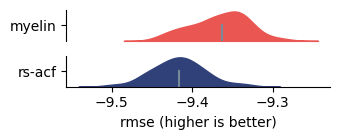

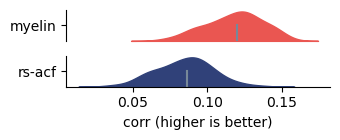

In [9]:
my_colors = get_my_colors(cat_trio=True, as_list=True)

# primary score
df_plot = pd.DataFrame(index=np.arange(n_rand_splits))
df_plot['myelin'] = regression_myelin.accuracy_mean
df_plot['rs-acf'] = regression_rsacf.accuracy_mean

df_plot = df_plot.melt()
value = '{:} (higher is better)'.format(score)
df_plot.rename(columns={'value': value}, inplace=True)
f = categorical_kde_plot(df=df_plot, variable=value, category='variable', horizontal=True, color_palette=my_colors, rug=False, fig_width=3.5, fig_height=1.5)

# secondary score
df_plot = pd.DataFrame(index=np.arange(n_rand_splits))
df_plot['myelin'] = regression_myelin.secondary_accuracy_mean
df_plot['rs-acf'] = regression_rsacf.secondary_accuracy_mean

df_plot = df_plot.melt()
value = '{:} (higher is better)'.format(secondary_score)
df_plot.rename(columns={'value': value}, inplace=True)
f = categorical_kde_plot(df=df_plot, variable=value, category='variable', horizontal=True, color_palette=my_colors, rug=False, fig_width=3.5, fig_height=1.5)

Second, plot the result for a permutation test (empirical null).

First for myelin:

Text(0.5, 0, 'corr (empirical null)')

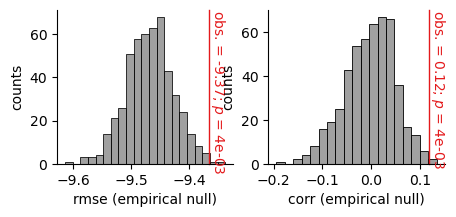

In [10]:
# primary score
f, ax = plt.subplots(1, 2, figsize=(5, 2))
observed = regression_myelin.accuracy_mean.mean()  # take the mean of the out-of-sample performance distribution a point estimate to compare against the null
null = regression_myelin.accuracy_perm
p_val = get_null_p(observed, null)
null_plot(observed, null, '', ax=ax[0], p_val=p_val)
ax[0].set_xlabel('{0} (empirical null)'.format(score))

# secondary score
observed = regression_myelin.secondary_accuracy_mean.mean()  # take the mean of the out-of-sample performance distribution a point estimate to compare against the null
null = regression_myelin.secondary_accuracy_perm
p_val = get_null_p(observed, null)
null_plot(observed, null, '', ax=ax[1], p_val=p_val)
ax[1].set_xlabel('{0} (empirical null)'.format(secondary_score))

And then for rsacf:

Text(0.5, 0, 'corr (empirical null)')

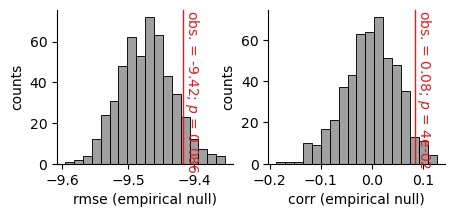

In [11]:
# primary score
f, ax = plt.subplots(1, 2, figsize=(5, 2))
observed = regression_rsacf.accuracy_mean.mean()  # take the mean of the out-of-sample performance distribution a point estimate to compare against the null
null = regression_rsacf.accuracy_perm
p_val = get_null_p(observed, null)
null_plot(observed, null, '', ax=ax[0], p_val=p_val)
ax[0].set_xlabel('{0} (empirical null)'.format(score))

# secondary score
observed = regression_rsacf.secondary_accuracy_mean.mean()  # take the mean of the out-of-sample performance distribution a point estimate to compare against the null
null = regression_rsacf.secondary_accuracy_perm
p_val = get_null_p(observed, null)
null_plot(observed, null, '', ax=ax[1], p_val=p_val)
ax[1].set_xlabel('{0} (empirical null)'.format(secondary_score))